# Lapage - Notebook statistique

Ce notebook regroupe les tests statistiques demandés pour le projet P9.

Objectifs :
- retirer les clients atypiques de type B2B avant les tests ;
- tester les liens entre genre et catégories achetées ;
- tester l'effet de l'âge sur plusieurs variables client ;
- garder des conclusions lisibles pour une soutenance non technique.


| Variable             | Type                     | Exemple d'usage statistique              |
|----------------------|--------------------------|------------------------------------------|
| genre                | Qualitative nominale     | khi² avec catégories                     |
| catégories           | Qualitative nominale     | khi² avec genre                          |
| tranche_âge          | Qualitative ordonnée     | ANOVA ou comparaison entre groupes       |
| âge                  | Quantitative             | corrélation de Pearson ou Spearman       |
| prix_unitaire     | Quantitative             | corrélation ou comparaison de moyennes   |
| nombre_commandes     | Quantitative             | analyse de fréquence d'achat             |
| commandes_par_mois   | Quantitative             | corrélation avec âge                     |
| montant_panier_moyen         | Quantitative             | analyse du montant moyen                 |
| taille_panier_moyen  | Quantitative             | corrélation avec âge                     |
| produits_vendus      | Quantitative             | volume acheté par client                 |

## 1. Imports et chargement des données

On recharge les données brutes ici pour garder un notebook autonome, avec les colonnes renommées en français comme dans le notebook principal.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from scipy.stats import (
    chi2_contingency,
    f_oneway,
    kruskal,
    pearsonr,
    shapiro,
    spearmanr,
)


In [2]:
candidats_racine = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
racine_projet = next((p for p in candidats_racine if (p / 'data' / 'raw').exists()), Path.cwd())
dossier_donnees = racine_projet / 'data' / 'raw'

transactions_path = dossier_donnees / 'transactions.csv'
if not transactions_path.exists():
    transactions_path = dossier_donnees / 'Transactions.csv'

clients = pd.read_csv(dossier_donnees / 'customers.csv', sep=';')
produits = pd.read_csv(dossier_donnees / 'products.csv', sep=';')
transactions = pd.read_csv(transactions_path, sep=';', low_memory=False)

transactions = transactions.dropna(how='all').copy()
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
transactions = transactions.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

ventes = (
    transactions
    .merge(produits, on='id_prod', how='left', validate='many_to_one')
    .merge(clients, on='client_id', how='left', validate='many_to_one')
)

ventes = ventes.rename(columns={
    'id_prod': 'id_produit',
    'categ': 'id_categorie',
    'price': 'chiffre_affaires',
    'session_id': 'id_session',
    'client_id': 'id_client',
    'sex': 'genre_code',
    'birth': 'année_naissance',
})

annee_reference = int(ventes['date'].dt.year.max())
ventes['année'] = ventes['date'].dt.year
ventes['mois'] = ventes['date'].dt.month
ventes['jour'] = ventes['date'].dt.day
ventes['période'] = ventes['date'].dt.to_period('M').dt.to_timestamp()
ventes['semaine'] = ventes['date'].dt.to_period('W-MON').dt.start_time
ventes['trimestre'] = ventes['date'].dt.to_period('Q').dt.start_time
ventes['âge'] = annee_reference - ventes['année_naissance']
ventes['tranche_âge'] = pd.cut(
    ventes['âge'],
    bins=[0, 24, 34, 44, 54, 64, 120],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    right=True,
    include_lowest=True,
)
ventes['genre'] = ventes['genre_code'].map({'f': 'Femmes', 'm': 'Hommes'}).fillna('Non renseigné')
ventes['catégories'] = ventes['id_categorie'].map({0: 'catégorie 0', 1: 'catégorie 1', 2: 'catégorie 2'})

print(f'Racine projet : {racine_projet}')
print(f'Nombre de lignes de ventes : {len(ventes):,}'.replace(',', ' '))
display(ventes.head())

seuil_p_value = 0.05


Racine projet : D:\openclassroom\P9
Nombre de lignes de ventes : 687 534


,id_produit,date,id_session,id_client,chiffre_affaires,id_categorie,genre_code,année_naissance,année,mois,jour,période,semaine,trimestre,âge,tranche_âge,genre,catégories
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,2021,3,1,2021-03-01,2021-02-23,2021-01-01,56,55-64,Femmes,catégorie 0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,2021,3,1,2021-03-01,2021-02-23,2021-01-01,63,55-64,Hommes,catégorie 0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,2021,3,1,2021-03-01,2021-02-23,2021-01-01,35,35-44,Hommes,catégorie 0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,2021,3,1,2021-03-01,2021-02-23,2021-01-01,34,25-34,Femmes,catégorie 0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,2021,3,1,2021-03-01,2021-02-23,2021-01-01,67,65+,Femmes,catégorie 0


## 2. Préparation des métriques clients et exclusion des clients atypiques

La fiche d'auto-évaluation demande de retirer les 4 clients atypiques B2B des analyses statistiques. On reprend la même logique de détection que dans le projet : des clients très extrêmes à  la fois en chiffre d'affaires et en nombre de commandes.


In [3]:
metriques_sessions = (
    ventes.groupby(['id_client', 'id_session'], as_index=False)
    .agg(
        panier=('chiffre_affaires', 'sum'),
        taille_panier=('id_produit', 'count'),
        date=('date', 'min'),
    )
)

metriques_clients = (
    ventes.groupby(['id_client', 'genre_code', 'genre', 'année_naissance', 'âge', 'tranche_âge'], as_index=False, observed=True)
    .agg(
        chiffre_affaires=('chiffre_affaires', 'sum'),
        produits_vendus=('id_produit', 'count'),
    )
    .merge(
        metriques_sessions.groupby('id_client', as_index=False).agg(
            nombre_commandes=('id_session', 'nunique'),
            panier_moyen=('panier', 'mean'),
            taille_panier_moyen=('taille_panier', 'mean'),
            premier_achat=('date', 'min'),
            dernier_achat=('date', 'max'),
        ),
        on='id_client',
        how='left',
    ).sort_values('tranche_âge', ascending=True)
)

metriques_clients['commandes_par_mois'] = (
    metriques_clients['nombre_commandes'] /
    ((metriques_clients['dernier_achat'] - metriques_clients['premier_achat']).dt.days.clip(lower=1) / 30.4375)
)
metriques_clients['part_chiffre_affaires'] = (
    metriques_clients['chiffre_affaires'] / metriques_clients['chiffre_affaires'].sum()
)

q1_ca = metriques_clients['chiffre_affaires'].quantile(0.25)
q3_ca = metriques_clients['chiffre_affaires'].quantile(0.75)
q1_cmd = metriques_clients['nombre_commandes'].quantile(0.25)
q3_cmd = metriques_clients['nombre_commandes'].quantile(0.75)

seuil_ca = q3_ca + 3 * (q3_ca - q1_ca)
seuil_cmd = q3_cmd + 3 * (q3_cmd - q1_cmd)

clients_b2b = metriques_clients.loc[
    (metriques_clients['chiffre_affaires'] >= seuil_ca)
    & (metriques_clients['nombre_commandes'] >= seuil_cmd)
].copy()

ids_b2b = clients_b2b['id_client'].tolist()
ventes_stats = ventes.loc[~ventes['id_client'].isin(ids_b2b)].copy()
metriques_clients_stats = metriques_clients.loc[~metriques_clients['id_client'].isin(ids_b2b)].copy()

resume_b2b = pd.DataFrame({
    'indicateur': ['clients atypiques détectés', 'lignes de ventes retirées', 'clients restants'],
    'valeur': [len(clients_b2b), len(ventes) - len(ventes_stats), metriques_clients_stats['id_client'].nunique()],
})

display(resume_b2b)
display(clients_b2b[['id_client', 'chiffre_affaires', 'nombre_commandes', 'panier_moyen']].sort_values('chiffre_affaires', ascending=False))


,indicateur,valeur
0,clients atypiques détectés,4
1,lignes de ventes retirées,46800
2,clients restants,8596


,id_client,chiffre_affaires,nombre_commandes,panier_moyen
677,c_1609,326039.89,10997,29.648076
4388,c_4958,290227.03,3851,75.364069
6337,c_6714,153918.60,2620,58.747557
2724,c_3454,114110.57,5571,20.482960


## 3. Test du Khi2 : lien entre genre et catégories achetées

Hypothèses :
- H0 : le genre et la catégorie achetée sont indépendants ;
- H1 : il existe une association entre le genre et la catégorie achetée.


In [4]:
pd.set_option('display.max_colwidth', None) #désactive le tronquage des tableaux

table_contingence = pd.crosstab(ventes_stats['genre'], ventes_stats['catégories'])
stat_khi2, p_value_khi2, ddl_khi2, effectifs_theoriques = chi2_contingency(table_contingence)

resultat_khi2 = pd.DataFrame({
    'statistique': [stat_khi2],
    'p_value': [p_value_khi2],
    'degrés_de_liberté': [ddl_khi2],
})

display(table_contingence)
display(resultat_khi2)


catégories,catégorie 0,catégorie 1,catégorie 2
genre,,,
Femmes,200793,115721,16980
Hommes,186488,104884,15868


,statistique,p_value,degrés_de_liberté
0,22.668567,0.000012,2


Lecture rapide : si la p-value est inférieure à  0,05, on rejette l'hypothèse d'indépendance et on considère qu'il existe un lien statistiquement significatif entre genre et catégories achetées.


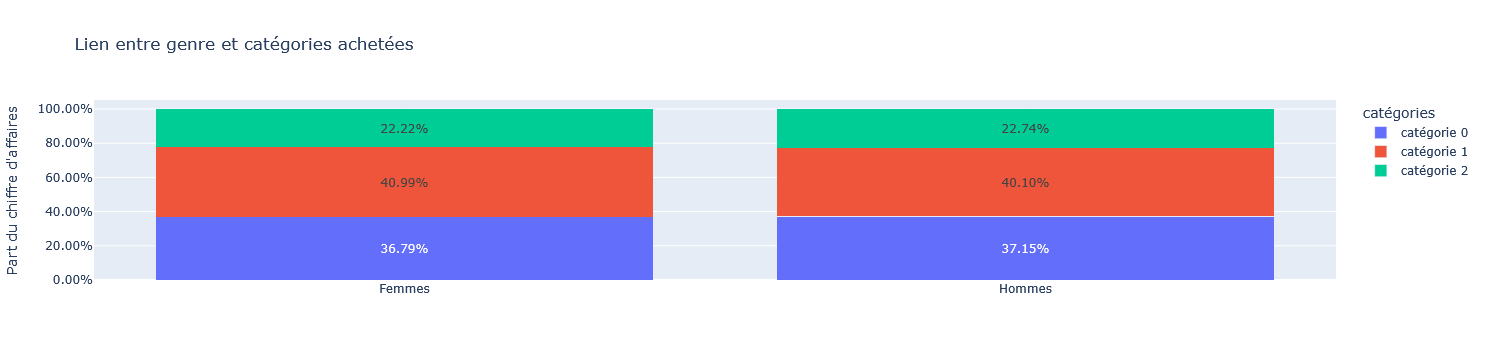

In [5]:
repartition_genre_categorie = (
    ventes_stats.groupby(['genre', 'catégories'], as_index=False)
    .agg(chiffre_affaires=('chiffre_affaires', 'sum'))
)
repartition_genre_categorie['part_chiffre_affaires'] = (
    repartition_genre_categorie['chiffre_affaires'] /
    repartition_genre_categorie.groupby('genre')['chiffre_affaires'].transform('sum')
)

figure_genre_categorie = px.bar(
    repartition_genre_categorie,
    x='genre',
    y='part_chiffre_affaires',
    color='catégories',
    text='part_chiffre_affaires',
    barmode='stack',
    title='Lien entre genre et catégories achetées'
)

figure_genre_categorie.update_traces(
    texttemplate='%{text:.2%}',
    textposition='inside',
    insidetextanchor='middle'
)

figure_genre_categorie.update_layout(xaxis_title='', yaxis_title="Part du chiffre d'affaires", yaxis_tickformat='.2%')
figure_genre_categorie.show()

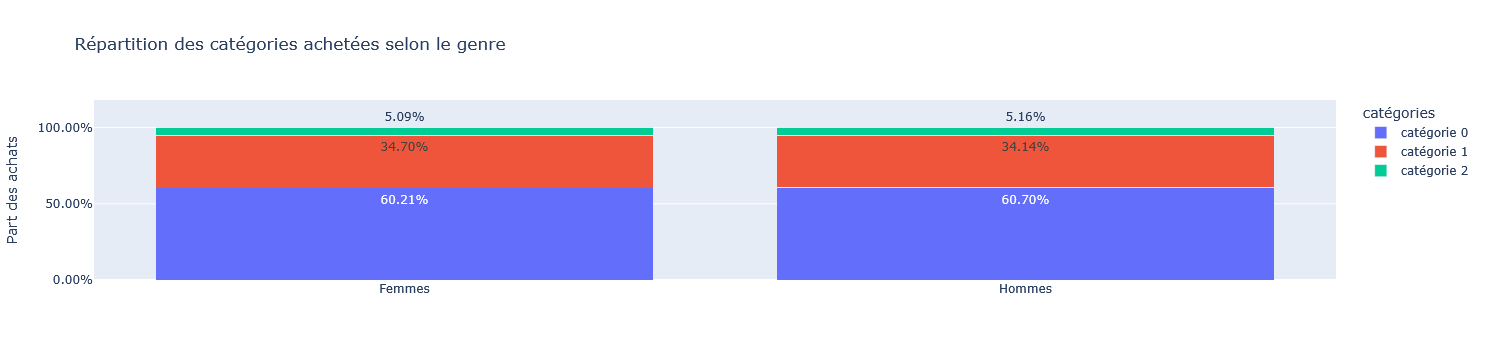

In [6]:
repartition_genre_categorie = (
    ventes_stats.groupby(['genre', 'catégories'], as_index=False)
    .agg(nombre_achats=('id_produit', 'count'))
)

repartition_genre_categorie['part_achats'] = (
    repartition_genre_categorie['nombre_achats'] /
    repartition_genre_categorie.groupby('genre')['nombre_achats'].transform('sum')
)

figure_genre_categorie = px.bar(
    repartition_genre_categorie,
    x='genre',
    y='part_achats',
    color='catégories',
    text='part_achats',
    barmode='stack',
    title='Répartition des catégories achetées selon le genre'
)

figure_genre_categorie.update_traces(
    texttemplate='%{text:.2%}',
    textposition='outside',
    insidetextanchor='middle'
)

figure_genre_categorie.update_layout(
    xaxis_title='',
    yaxis_title="Part des achats",
    yaxis_tickformat='.2%'
)

figure_genre_categorie.show()

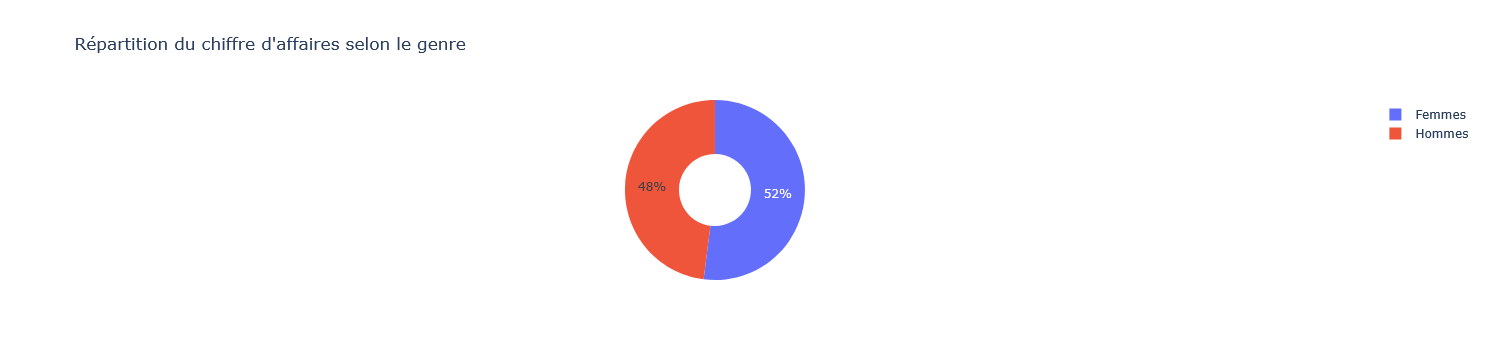

In [7]:
repartition_ca_genre = (
    metriques_clients_stats.groupby('genre', as_index=False)
    .agg(chiffre_affaires=('chiffre_affaires', 'sum'))
)

figure_ca_genre = px.pie(
    repartition_ca_genre,
    names='genre',
    values='chiffre_affaires',
    hole=0.4,
    title="Répartition du chiffre d'affaires selon le genre"
)

figure_ca_genre.update_traces(
    textinfo='percent+label'
)

figure_ca_genre = px.pie(
    repartition_ca_genre,
    names='genre',
    values='chiffre_affaires',
    hole=0.4,
    title="Répartition du chiffre d'affaires selon le genre",
    hover_data=['chiffre_affaires']
)

figure_ca_genre.show()


## 4. Effet de la tranche d'âge sur le chiffre d'affaires client


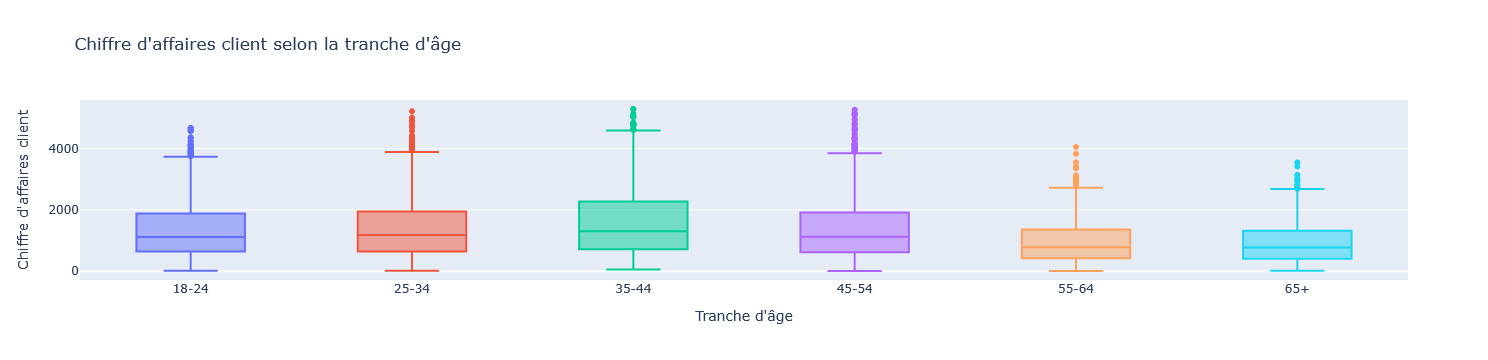

In [8]:
figure_anova = px.box(
    metriques_clients_stats,
    x='tranche_âge',
    y='chiffre_affaires',
    color='tranche_âge',
    title="Chiffre d'affaires client selon la tranche d'âge"
)
figure_anova.update_layout(xaxis_title="Tranche d'âge", yaxis_title="Chiffre d'affaires client")
figure_anova.update_layout(showlegend=False)
figure_anova.show()


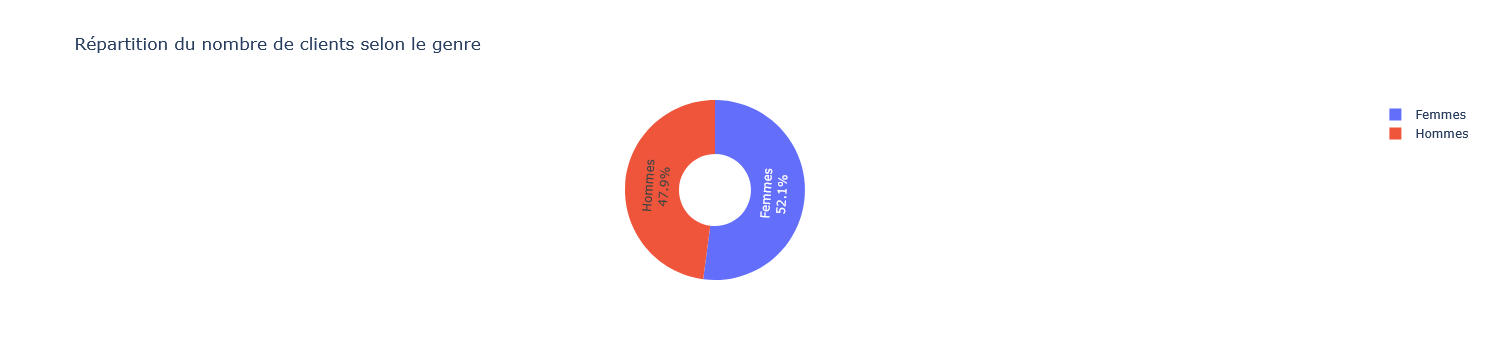

In [9]:
repartition_clients_genre = (
    metriques_clients_stats.groupby('genre', as_index=False)
    .agg(nombre_clients=('id_client', 'count'))
)

figure_clients_genre = px.pie(
    repartition_clients_genre,
    names='genre',
    values='nombre_clients',
    hole=0.4,
    title="Répartition du nombre de clients selon le genre"
)

figure_clients_genre.update_traces(
    textinfo='percent+label'
)

figure_clients_genre.show()

In [10]:
groupes_anova = []
tests_normalite_anova = []

for tranche_age, groupe in metriques_clients_stats.groupby('tranche_âge', observed=True):
    valeurs = groupe['chiffre_affaires'].dropna()
    if len(valeurs) >= 2:
        groupes_anova.append((tranche_age, valeurs))

        echantillon_normalite = valeurs
        # Shapiro-Wilk devient moins fiable au-delà de 5000 valeurs ; on plafonne donc l'échantillon testé.
        if len(echantillon_normalite) > 5000:
            echantillon_normalite = echantillon_normalite.sample(5000, random_state=42)

        stat_shapiro, p_value_shapiro = shapiro(echantillon_normalite)
        tests_normalite_anova.append({
            'tranche_âge': tranche_age,
            'effectif_testé': len(echantillon_normalite),
            'statistique_shapiro': stat_shapiro,
            'p_value': p_value_shapiro,
            'conclusion': 'Normalité non rejetée' if p_value_shapiro >= seuil_p_value else 'Normalité rejetée',
        })

resultats_normalite_anova = pd.DataFrame(tests_normalite_anova)
display(resultats_normalite_anova)

normalite_ok_anova = resultats_normalite_anova['p_value'].ge(seuil_p_value).all()

if normalite_ok_anova:
    resultat_test_anova = f_oneway(*[valeurs for _, valeurs in groupes_anova])
    nom_test_anova = 'ANOVA'
    micro_conclusion_anova = "La normalité n'est pas rejetée dans les groupes : l'ANOVA est retenue."
else:
    resultat_test_anova = kruskal(*[valeurs for _, valeurs in groupes_anova])
    nom_test_anova = 'Kruskal-Wallis'
    micro_conclusion_anova = "La normalité est rejetée dans au moins un groupe : le test de Kruskal-Wallis est retenu."

stat_anova = float(resultat_test_anova.statistic)
p_value_anova = float(resultat_test_anova.pvalue)

resultat_anova = pd.DataFrame({
    'test_retenu': [nom_test_anova],
    'statistique': [stat_anova],
    'p_value': [p_value_anova],
    'micro_conclusion': [micro_conclusion_anova],
    'conclusion': ['Différence significative' if p_value_anova < seuil_p_value else 'Pas de différence significative'],
})
display(resultat_anova)


,tranche_âge,effectif_testé,statistique_shapiro,p_value,conclusion
0,18-24,1146,0.926540,3.081217e-23,Normalité rejetée
1,25-34,1561,0.922675,1.389165e-27,Normalité rejetée
2,35-44,1779,0.919943,1.003153e-29,Normalité rejetée
3,45-54,1609,0.908400,4.702849e-30,Normalité rejetée
4,55-64,1228,0.912494,5.224666e-26,Normalité rejetée
5,65+,1273,0.924387,8.613137e-25,Normalité rejetée


,test_retenu,statistique,p_value,micro_conclusion,conclusion
0,Kruskal-Wallis,499.471106,1.038527e-105,La normalité est rejetée dans au moins un groupe : le test de Kruskal-Wallis est retenu.,Différence significative


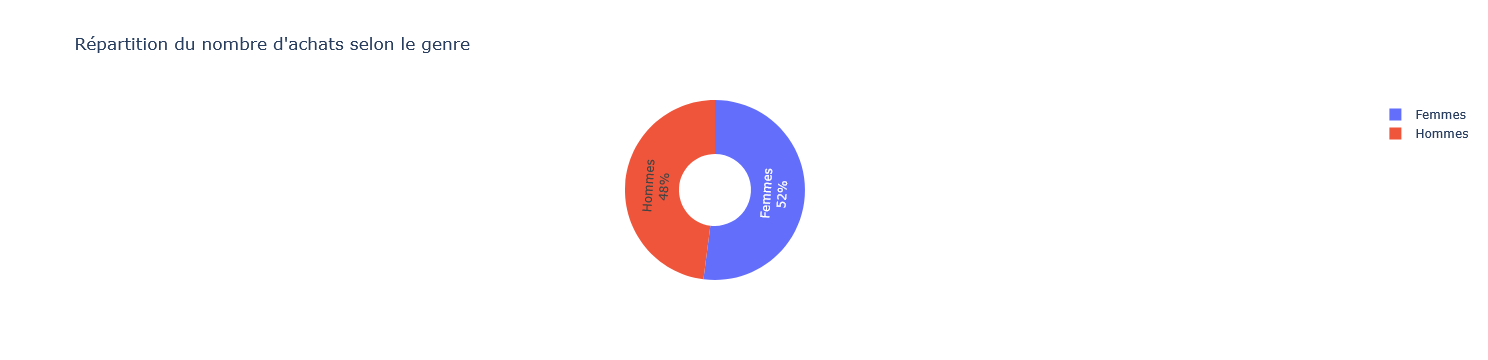

In [11]:
repartition_achats_genre = (
    ventes_stats.groupby('genre', as_index=False)
    .agg(nombre_achats=('id_produit', 'count'))
)

figure_achats_genre = px.pie(
    repartition_achats_genre,
    names='genre',
    values='nombre_achats',
    hole=0.4,
    title="Répartition du nombre d'achats selon le genre"
)

figure_achats_genre.update_traces(
    textinfo='percent+label'
)

figure_achats_genre.show()

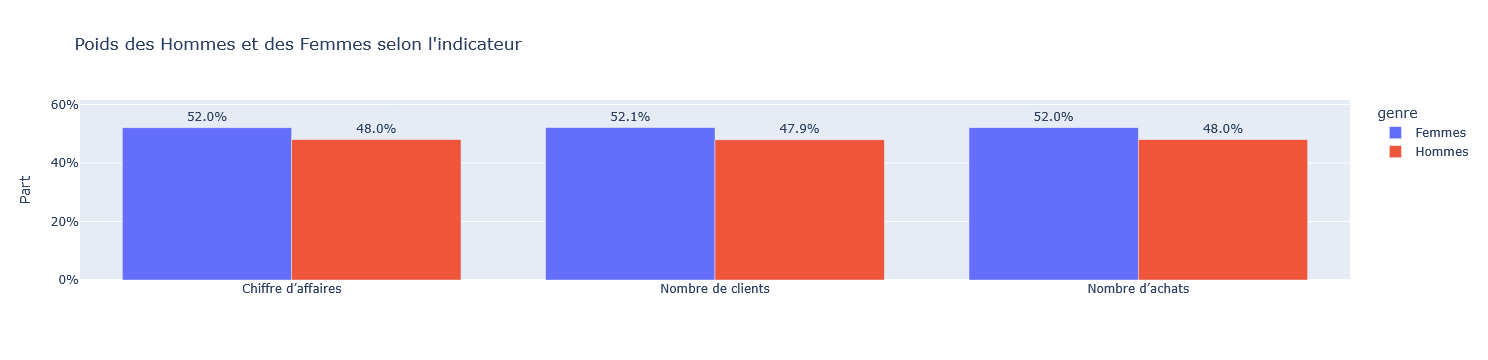

In [12]:
repartition_ca_genre = (
    metriques_clients_stats.groupby('genre', as_index=False)
    .agg(chiffre_affaires=('chiffre_affaires', 'sum'))
)

repartition_clients_genre = (
    metriques_clients_stats.groupby('genre', as_index=False)
    .agg(nombre_clients=('id_client', 'count'))
)

repartition_achats_genre = (
    ventes_stats.groupby('genre', as_index=False)
    .agg(nombre_achats=('id_produit', 'count'))
)

comparaison_genre = (
    repartition_ca_genre
    .merge(repartition_clients_genre, on='genre')
    .merge(repartition_achats_genre, on='genre')
)

comparaison_genre_long = comparaison_genre.melt(
    id_vars='genre',
    value_vars=['chiffre_affaires', 'nombre_clients', 'nombre_achats'],
    var_name='indicateur',
    value_name='valeur_brute'
)

comparaison_genre_long['part'] = (
    comparaison_genre_long['valeur_brute'] /
    comparaison_genre_long.groupby('indicateur')['valeur_brute'].transform('sum')
)

comparaison_genre_long['indicateur'] = comparaison_genre_long['indicateur'].replace({
    'chiffre_affaires': 'Chiffre d’affaires',
    'nombre_clients': 'Nombre de clients',
    'nombre_achats': 'Nombre d’achats'
})

figure_comparaison_genre = px.bar(
    comparaison_genre_long,
    x='indicateur',
    y='part',
    color='genre',
    barmode='group',
    text='part',
    title="Poids des Hommes et des Femmes selon l'indicateur",
    hover_data={
        'part': ':.1%',
        'valeur_brute': True
    }
)

figure_comparaison_genre.update_traces(
    texttemplate='%{text:.1%}',
    textposition='outside'
)

figure_comparaison_genre.update_layout(
    xaxis_title='',
    yaxis_title='Part',
    yaxis_tickformat='.0%'
)

figure_comparaison_genre.show()

## 5. Lien entre l'âge et le chiffre d'affaires client


In [13]:
echantillon_age = metriques_clients_stats['âge'].dropna()
# Shapiro-Wilk, limitation à 5000 valeurs pseudo aléatoire
if len(echantillon_age) > 5000:
    echantillon_age = echantillon_age.sample(5000, random_state=42)

echantillon_variable = metriques_clients_stats['chiffre_affaires'].dropna()
if len(echantillon_variable) > 5000:
    echantillon_variable = echantillon_variable.sample(5000, random_state=42)

stat_shapiro_age, p_value_shapiro_age = shapiro(echantillon_age)
stat_shapiro_variable, p_value_shapiro_variable = shapiro(echantillon_variable)

resultat_normalite = pd.DataFrame({
    'variable': ['âge', 'variable étudiée'],
    'effectif_testé': [len(echantillon_age), len(echantillon_variable)],
    'statistique_shapiro': [stat_shapiro_age, stat_shapiro_variable],
    'p_value': [p_value_shapiro_age, p_value_shapiro_variable],
    'conclusion': [
        'Normalité non rejetée' if p_value_shapiro_age >= seuil_p_value else 'Normalité rejetée',
        'Normalité non rejetée' if p_value_shapiro_variable >= seuil_p_value else 'Normalité rejetée',
    ],
})
resultat_normalite.loc[1, 'variable'] = 'chiffre_affaires'
display(resultat_normalite)

donnees_chiffre_affaires = metriques_clients_stats[['âge', 'chiffre_affaires']].dropna()

if p_value_shapiro_age >= seuil_p_value and p_value_shapiro_variable >= seuil_p_value:
    correlation_age_ca = pearsonr(donnees_chiffre_affaires['âge'], donnees_chiffre_affaires['chiffre_affaires'])
    nom_test_age_ca = 'Pearson'
    micro_conclusion_chiffre_affaires = "La normalité n'est pas rejetée pour l'âge et le chiffre d'affaires client : le test de Pearson est retenu."
else:
    correlation_age_ca = spearmanr(donnees_chiffre_affaires['âge'], donnees_chiffre_affaires['chiffre_affaires'])
    nom_test_age_ca = 'Spearman'
    micro_conclusion_chiffre_affaires = "La normalité est rejetée pour au moins une variable : le test de Spearman est retenu."

resultat_correlation_age_ca = pd.DataFrame({
    'test_retenu': [nom_test_age_ca],
    'statistique': [float(correlation_age_ca.statistic)],
    'p_value': [float(correlation_age_ca.pvalue)],
    'micro_conclusion': [micro_conclusion_chiffre_affaires],
    'conclusion': ['Relation significative' if float(correlation_age_ca.pvalue) < 0.05 else 'Pas de relation significative'],
})
display(resultat_correlation_age_ca)


,variable,effectif_testé,statistique_shapiro,p_value,conclusion
0,âge,5000,0.969831,3.506071e-31,Normalité rejetée
1,chiffre_affaires,5000,0.906246,3.937654e-48,Normalité rejetée


,test_retenu,statistique,p_value,micro_conclusion,conclusion
0,Spearman,-0.184538,1.021291e-66,La normalité est rejetée pour au moins une variable : le test de Spearman est retenu.,Relation significative


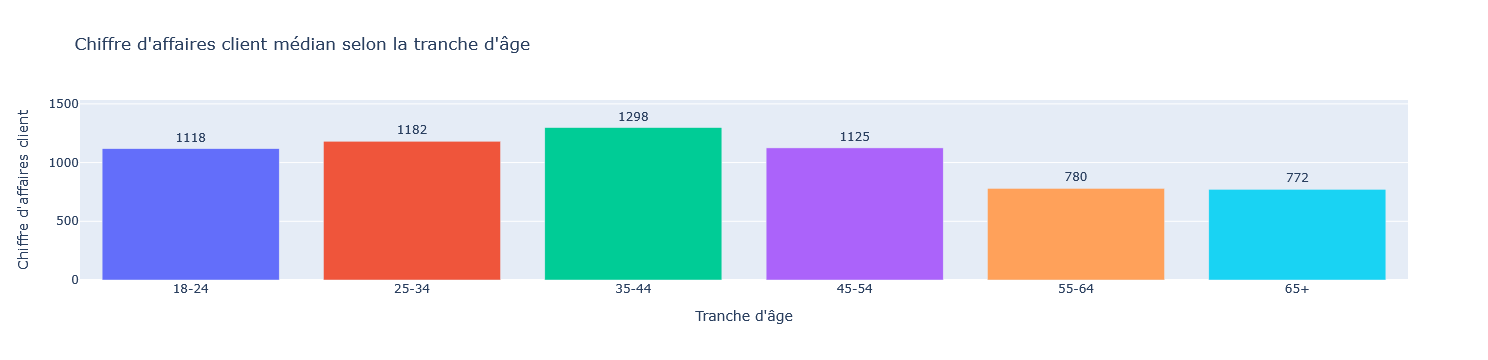

In [14]:
#figure_age_ca = px.scatter(
#    metriques_clients_stats,
#    x='âge',
#    y='chiffre_affaires',
#    color='genre',
#    opacity=0.7,
#    title="Lien entre l'âge et le montant total des achats",
#    hover_data=['id_client', 'nombre_commandes', 'panier_moyen']
#)
#figure_age_ca.update_layout(xaxis_title='âge', yaxis_title="Chiffre d'affaires client")


ca_par_tranche_age = (
    metriques_clients_stats.groupby('tranche_âge', as_index=False, observed=False)
    .agg(chiffre_affaires=('chiffre_affaires', 'median'))
)

figure_age_ca = px.bar(
    ca_par_tranche_age,
    x='tranche_âge',
    y='chiffre_affaires',
    text='chiffre_affaires',
    color='tranche_âge',
    title="Chiffre d'affaires client médian selon la tranche d'âge"
)

figure_age_ca.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside'
)

figure_age_ca.update_layout(
    xaxis_title="Tranche d'âge",
    yaxis_title="Chiffre d'affaires client",
    showlegend=False
)

figure_age_ca.show()

In [15]:
echantillon_age = metriques_clients_stats['âge'].dropna()
# Shapiro-Wilk, limitation à 5000 valeurs pseudo aléatoire
if len(echantillon_age) > 5000:
    echantillon_age = echantillon_age.sample(5000, random_state=42)

echantillon_variable = metriques_clients_stats['commandes_par_mois'].dropna()
if len(echantillon_variable) > 5000:
    echantillon_variable = echantillon_variable.sample(5000, random_state=42)

stat_shapiro_age, p_value_shapiro_age = shapiro(echantillon_age)
stat_shapiro_variable, p_value_shapiro_variable = shapiro(echantillon_variable)

resultat_normalite = pd.DataFrame({
    'variable': ['âge', 'variable étudiée'],
    'effectif_testé': [len(echantillon_age), len(echantillon_variable)],
    'statistique_shapiro': [stat_shapiro_age, stat_shapiro_variable],
    'p_value': [p_value_shapiro_age, p_value_shapiro_variable],
    'conclusion': [
        'Normalité non rejetée' if p_value_shapiro_age >= seuil_p_value else 'Normalité rejetée',
        'Normalité non rejetée' if p_value_shapiro_variable >= seuil_p_value else 'Normalité rejetée',
    ],
})
resultat_normalite.loc[1, 'variable'] = 'commandes_par_mois'
display(resultat_normalite)

donnees_commandes_par_mois = metriques_clients_stats[['âge', 'commandes_par_mois']].dropna()

if p_value_shapiro_age >= seuil_p_value and p_value_shapiro_variable >= seuil_p_value:
    correlation_age_frequence = pearsonr(donnees_commandes_par_mois['âge'], donnees_commandes_par_mois['commandes_par_mois'])
    nom_test_age_frequence = 'Pearson'
    micro_conclusion_commandes_par_mois = "La normalité n'est pas rejetée pour l'âge et la fréquence d'achat : le test de Pearson est retenu."
else:
    correlation_age_frequence = spearmanr(donnees_commandes_par_mois['âge'], donnees_commandes_par_mois['commandes_par_mois'])
    nom_test_age_frequence = 'Spearman'
    micro_conclusion_commandes_par_mois = "La normalité est rejetée pour au moins une variable : le test de Spearman est retenu."

resultat_correlation_age_frequence = pd.DataFrame({
    'test_retenu': [nom_test_age_frequence],
    'statistique': [float(correlation_age_frequence.statistic)],
    'p_value': [float(correlation_age_frequence.pvalue)],
    'micro_conclusion': [micro_conclusion_commandes_par_mois],
    'conclusion': ['Relation significative' if float(correlation_age_frequence.pvalue) < 0.05 else 'Pas de relation significative'],
})
display(resultat_correlation_age_frequence)


,variable,effectif_testé,statistique_shapiro,p_value,conclusion
0,âge,5000,0.969831,3.506071e-31,Normalité rejetée
1,commandes_par_mois,5000,0.525595,5.121282e-79,Normalité rejetée


,test_retenu,statistique,p_value,micro_conclusion,conclusion
0,Spearman,0.208832,2.520360e-85,La normalité est rejetée pour au moins une variable : le test de Spearman est retenu.,Relation significative


## 6. Lien entre l'âge et la fréquence d'achat


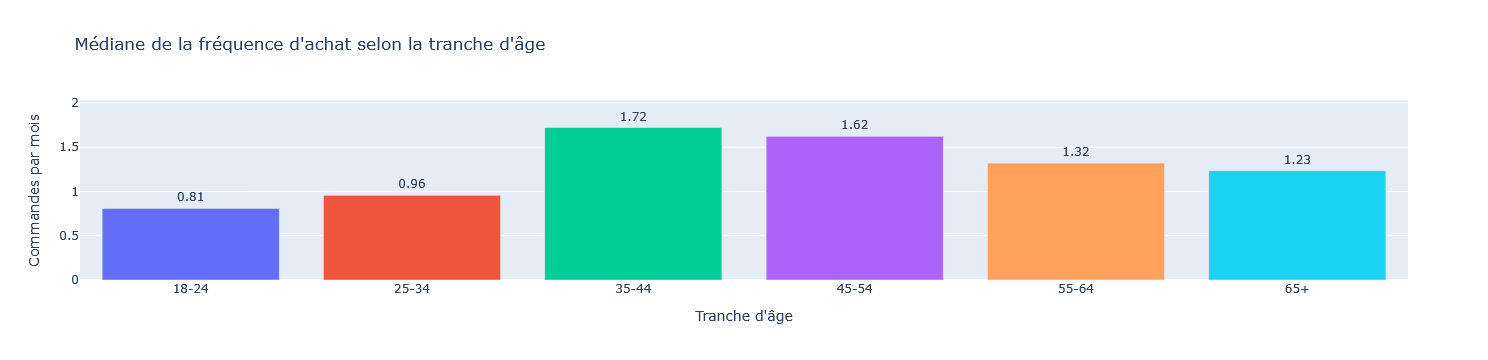

In [16]:
frequence_par_tranche_age = (
    metriques_clients_stats.groupby('tranche_âge', as_index=False, observed=False)
    .agg(commandes_par_mois=('commandes_par_mois', 'median'))
)

figure_age_frequence = px.bar(
    frequence_par_tranche_age,
    x='tranche_âge',
    y='commandes_par_mois',
    text='commandes_par_mois',
    color='tranche_âge',
    title="Médiane de la fréquence d'achat selon la tranche d'âge"
)

figure_age_frequence.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

figure_age_frequence.update_layout(
    xaxis_title="Tranche d'âge",
    yaxis_title='Commandes par mois',
    showlegend=False
)

figure_age_frequence.show()

## 7. Lien entre l'âge et la taille du panier moyen


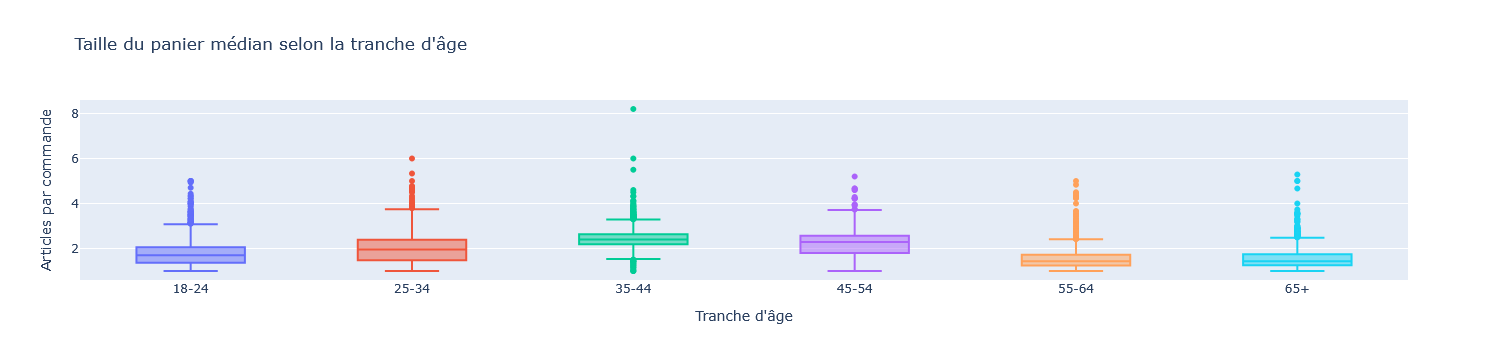

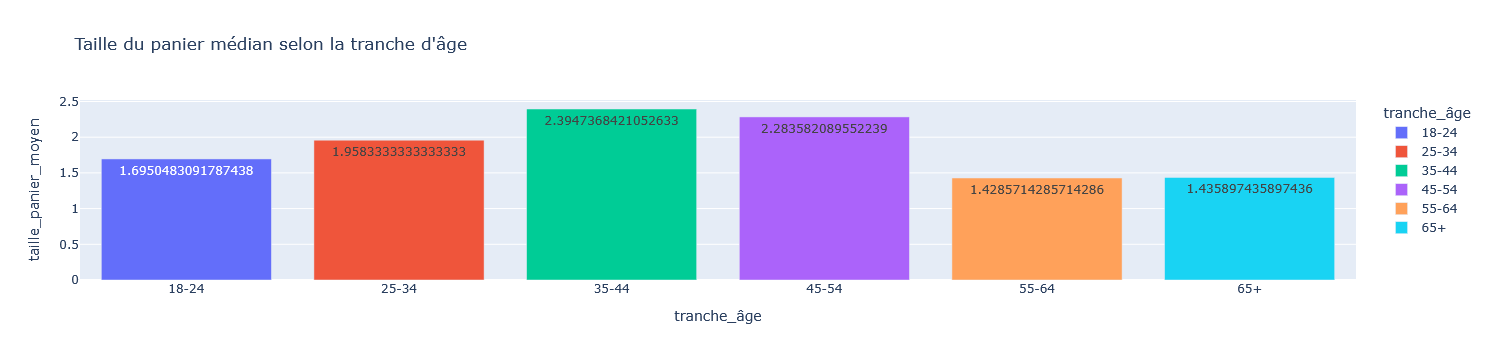

In [17]:
figure_age_panier = px.box(
    metriques_clients_stats,
    x='tranche_âge',
    y='taille_panier_moyen',
    color='tranche_âge',
    title="Taille du panier médian selon la tranche d'âge"
)

figure_age_panier.update_layout(
    xaxis_title="Tranche d'âge",
    yaxis_title='Articles par commande',
    showlegend=False
)

figure_age_panier.show()

panier_par_tranche_age = (
    metriques_clients_stats.groupby('tranche_âge', as_index=False, observed=False)
    .agg(taille_panier_moyen=('taille_panier_moyen', 'median'))
)

figure_age_panier = px.bar(
    panier_par_tranche_age,
    x='tranche_âge',
    y='taille_panier_moyen',
    text='taille_panier_moyen',
    color='tranche_âge',
    title="Taille du panier médian selon la tranche d'âge"
)

figure_age_panier.show()


In [18]:
echantillon_age = metriques_clients_stats['âge'].dropna()
# Shapiro-Wilk, limitation à 5000 valeurs pseudo aléatoire
if len(echantillon_age) > 5000:
    echantillon_age = echantillon_age.sample(5000, random_state=42)

echantillon_variable = metriques_clients_stats['taille_panier_moyen'].dropna()
if len(echantillon_variable) > 5000:
    echantillon_variable = echantillon_variable.sample(5000, random_state=42)

stat_shapiro_age, p_value_shapiro_age = shapiro(echantillon_age)
stat_shapiro_variable, p_value_shapiro_variable = shapiro(echantillon_variable)

resultat_normalite = pd.DataFrame({
    'variable': ['âge', 'variable étudiée'],
    'effectif_testé': [len(echantillon_age), len(echantillon_variable)],
    'statistique_shapiro': [stat_shapiro_age, stat_shapiro_variable],
    'p_value': [p_value_shapiro_age, p_value_shapiro_variable],
    'conclusion': [
        'Normalité non rejetée' if p_value_shapiro_age >= seuil_p_value else 'Normalité rejetée',
        'Normalité non rejetée' if p_value_shapiro_variable >= seuil_p_value else 'Normalité rejetée',
    ],
})
resultat_normalite.loc[1, 'variable'] = 'taille_panier_moyen'
display(resultat_normalite)

donnees_taille_panier_moyen = metriques_clients_stats[['âge', 'taille_panier_moyen']].dropna()

if p_value_shapiro_age >= seuil_p_value and p_value_shapiro_variable >= seuil_p_value:
    correlation_age_panier = pearsonr(donnees_taille_panier_moyen['âge'], donnees_taille_panier_moyen['taille_panier_moyen'])
    nom_test_age_panier = 'Pearson'
    micro_conclusion_taille_panier_moyen = "La normalité n'est pas rejetée pour l'âge et la taille du panier moyen : le test de Pearson est retenu."
else:
    correlation_age_panier = spearmanr(donnees_taille_panier_moyen['âge'], donnees_taille_panier_moyen['taille_panier_moyen'])
    nom_test_age_panier = 'Spearman'
    micro_conclusion_taille_panier_moyen = "La normalité est rejetée pour au moins une variable : le test de Spearman est retenu."

resultat_correlation_age_panier = pd.DataFrame({
    'test_retenu': [nom_test_age_panier],
    'statistique': [float(correlation_age_panier.statistic)],
    'p_value': [float(correlation_age_panier.pvalue)],
    'micro_conclusion': [micro_conclusion_taille_panier_moyen],
    'conclusion': ['Relation significative' if float(correlation_age_panier.pvalue) < 0.05 else 'Pas de relation significative'],
})
display(resultat_correlation_age_panier)


,variable,effectif_testé,statistique_shapiro,p_value,conclusion
0,âge,5000,0.969831,3.506071e-31,Normalité rejetée
1,taille_panier_moyen,5000,0.944646,8.857358e-40,Normalité rejetée


,test_retenu,statistique,p_value,micro_conclusion,conclusion
0,Spearman,-0.207715,2.045440e-84,La normalité est rejetée pour au moins une variable : le test de Spearman est retenu.,Relation significative


## 8. Synthèse des tests statistiques

On regroupe les principaux résultats pour avoir une lecture rapide avant de préparer le support de présentation.


In [19]:
synthese_tests = pd.DataFrame([
    {
        'test': 'Khi2 genre vs catégories',
        'test_retenu': 'Khi2',
        'statistique': stat_khi2,
        'p_value': p_value_khi2,
        'micro_conclusion': "Test adapté à deux variables qualitatives.",
        'conclusion': 'Lien significatif' if p_value_khi2 < 0.05 else 'Pas de lien significatif',
    },
    {
        'test': "Tranche d'âge vs chiffre d'affaires",
        'test_retenu': nom_test_anova,
        'statistique': stat_anova,
        'p_value': p_value_anova,
        'micro_conclusion': micro_conclusion_anova,
        'conclusion': 'Différence significative' if p_value_anova < 0.05 else 'Pas de différence significative',
    },
    {
        'test': "Âge vs chiffre d'affaires",
        'test_retenu': nom_test_age_ca,
        'statistique': float(correlation_age_ca.statistic),
        'p_value': float(correlation_age_ca.pvalue),
        'micro_conclusion': resultat_correlation_age_ca.loc[0, 'micro_conclusion'],
        'conclusion': 'Corrélation significative' if float(correlation_age_ca.pvalue) < 0.05 else 'Pas de corrélation significative',
    },
    {
        'test': 'Âge vs fréquence',
        'test_retenu': nom_test_age_frequence,
        'statistique': float(correlation_age_frequence.statistic),
        'p_value': float(correlation_age_frequence.pvalue),
        'micro_conclusion': resultat_correlation_age_frequence.loc[0, 'micro_conclusion'],
        'conclusion': 'Corrélation significative' if float(correlation_age_frequence.pvalue) < 0.05 else 'Pas de corrélation significative',
    },
    {
        'test': 'Âge vs taille du panier moyen',
        'test_retenu': nom_test_age_panier,
        'statistique': float(correlation_age_panier.statistic),
        'p_value': float(correlation_age_panier.pvalue),
        'micro_conclusion': resultat_correlation_age_panier.loc[0, 'micro_conclusion'],
        'conclusion': 'Corrélation significative' if float(correlation_age_panier.pvalue) < 0.05 else 'Pas de corrélation significative',
    },
])

synthese_tests['p_value'] = synthese_tests['p_value'].map(lambda x: f'{x:.3e}')
synthese_tests['statistique'] = synthese_tests['statistique'].map(lambda x: f'{x:.4f}')
display(synthese_tests)


,test,test_retenu,statistique,p_value,micro_conclusion,conclusion
0,Khi2 genre vs catégories,Khi2,22.6686,1.196e-05,Test adapté à deux variables qualitatives.,Lien significatif
1,Tranche d'âge vs chiffre d'affaires,Kruskal-Wallis,499.4711,1.039e-105,La normalité est rejetée dans au moins un groupe : le test de Kruskal-Wallis est retenu.,Différence significative
2,Âge vs chiffre d'affaires,Spearman,-0.1845,1.021e-66,La normalité est rejetée pour au moins une variable : le test de Spearman est retenu.,Corrélation significative
3,Âge vs fréquence,Spearman,0.2088,2.520e-85,La normalité est rejetée pour au moins une variable : le test de Spearman est retenu.,Corrélation significative
4,Âge vs taille du panier moyen,Spearman,-0.2077,2.045e-84,La normalité est rejetée pour au moins une variable : le test de Spearman est retenu.,Corrélation significative


## 9. Conclusion rapide

- les tests sont réalisés après retrait des clients atypiques B2B ;
- le khi2 permet de traiter une relation entre deux variables qualitatives ;
- l'ANOVA permet de comparer une variable quantitative entre plusieurs groupes ;
- Pearson permet de mesurer une relation linéaire entre deux variables quantitatives ;
- la conclusion finale doit toujours combiner résultat statistique et lecture métier.
